# **Introduction to Machine Learning in Frontline Urban Forest Management**


Machine learning offers significant advantages for prediction and classification, particularly in urban forest management strategies during frontline inspections. By adopting machine learning, we can enhance the efficiency of resource deployment. Here are the key benefits:

1.   Resource Allocation
2.   Customized Management Strategies
3.   Visual Data Representation

**Resource Allocation**:

Machine learning clustering facilitates optimal resource allocation, including manpower and equipment. By identifying high-priority zones based on tree density, we can ensure that resources are directed where they are most needed, maximizing operational efficiency.

**Customized Management Strategies**:

Different clusters identified through machine learning may have unique management requirements. This enables us to develop tailored strategies that address specific ecological or community goals, ensuring that our management efforts are both effective and relevant.

**Visual Data Representation**:

The results of clustering can be effectively visualized on maps. This visual representation simplifies the communication of findings and strategies to stakeholders, enhancing transparency and fostering collaboration among urban planners, community members, and environmental organizations.

Before - Without Clustering ❌
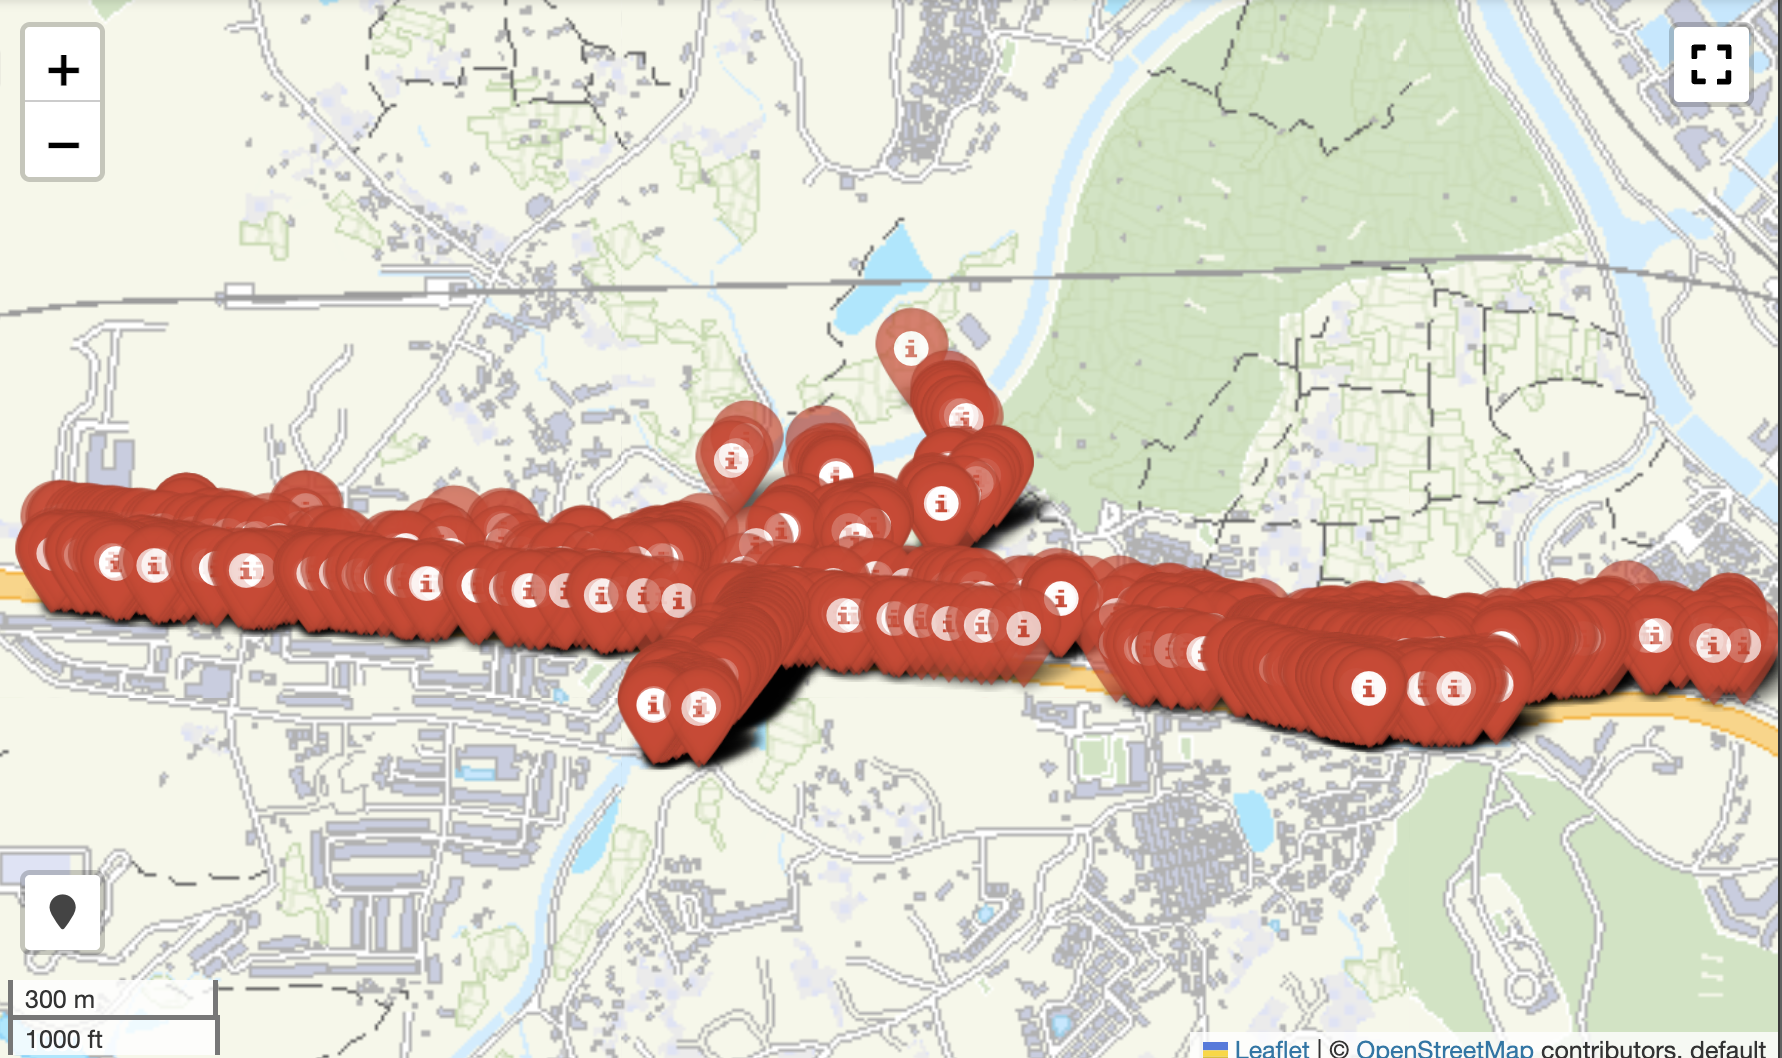

After - With Clustering ✅
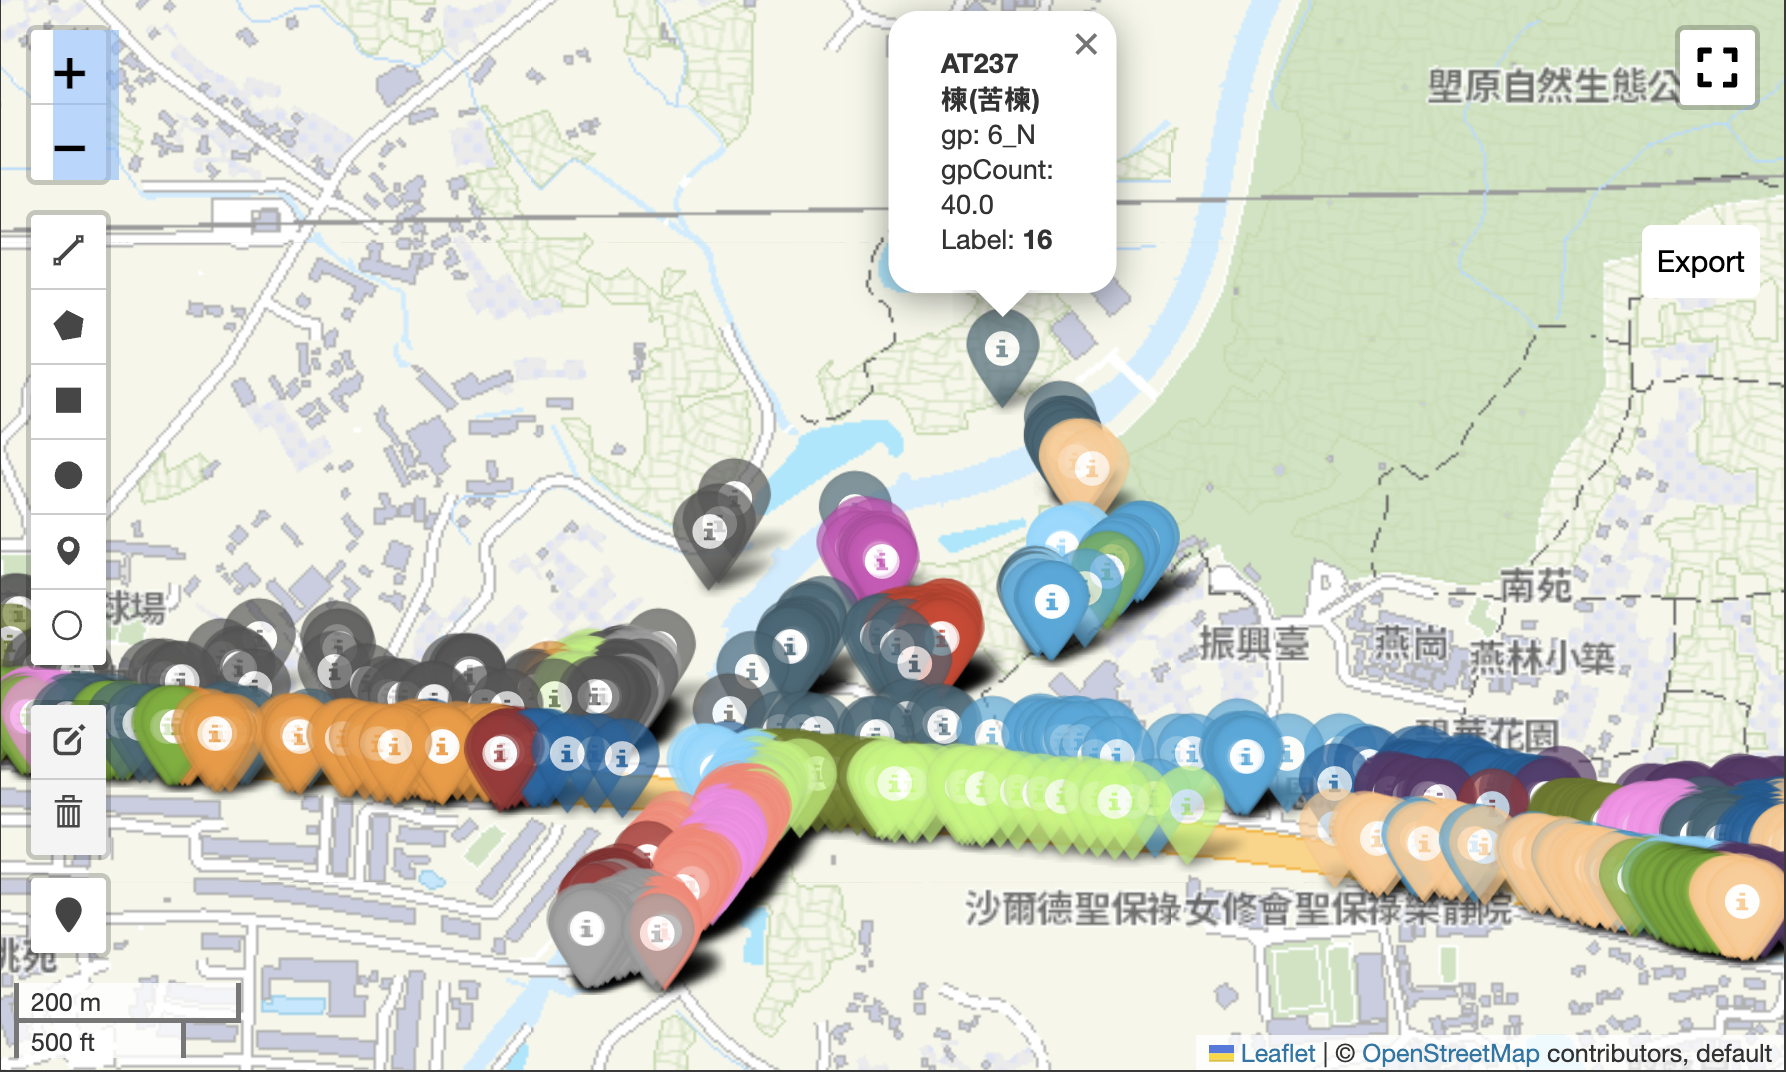


# Load Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# URL to the Google Sheet in CSV format
url = "https://docs.google.com/spreadsheets/d/1qWEyuezZVf_g4p76Ih3LWAmYQHoLmJz6KP0N-rm2SHc/gviz/tq?tqx=out:csv&gid=2111668742"

# Read the CSV data into a DataFrame
dfRaw = pd.read_csv(url)

dfRaw.columns.tolist()
df0 = dfRaw[['Tree No.', 'X', 'Y']]
df0 = df0[~df0['X'].isna()]
df0



,Tree No.,X,Y
0,T146,827956.460,840484.030
1,T147,827963.750,840483.450
2,T148,827970.440,840483.010
3,T151,827991.460,840480.370
4,T152,827998.880,840480.050
...,...,...,...
1513,AT296,829228.223,840509.458
1514,AT297,829229.876,840508.632
1515,AT299,829229.447,840508.351
1516,AT300,829282.429,840543.140


In [3]:
dfErrorX = dfRaw[dfRaw['X'].isna()]
numOfXYMissing = len(dfErrorX)
print(f'num of Error: {numOfXYMissing}')
dfErrorX

num of Error: 2


,Tree No.,Chinese name,DBH (mm),Height (m),Crown spread (m),Recommendation,Additional Remarks,X,Y,count,group,grouppingCount,F2 Pruning,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
487,T814,(死樹),156.0,7.0,4.0,Retain,Felled,NaN,NaN,2,miss,NaN,NaN,NaN,NaN,NaN,NaN
610,T03212,血桐,NaN,NaN,NaN,Remove,Missing,NaN,NaN,2,miss,NaN,NaN,NaN,NaN,NaN,NaN


# df Treatment

In [4]:
df0
dfInv = df0[~df0['Tree No.'].str.startswith('TG')]
dfGp = df0[df0['Tree No.'].str.startswith('TG')]

# Simple K-means clustering

Clustering resuslt without size constraint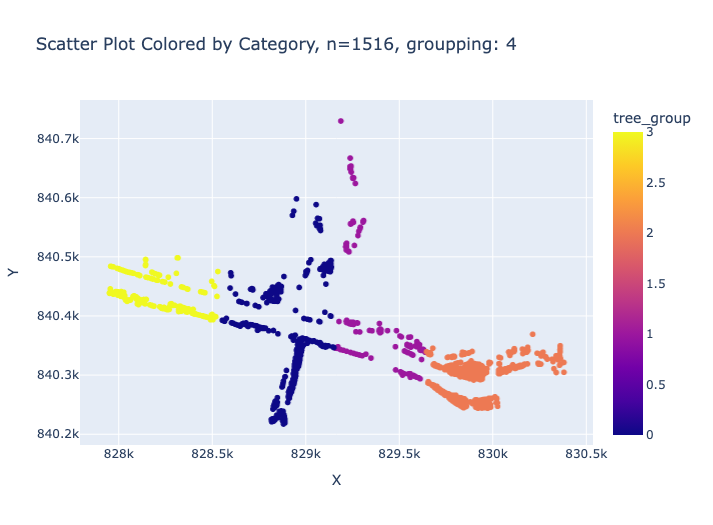



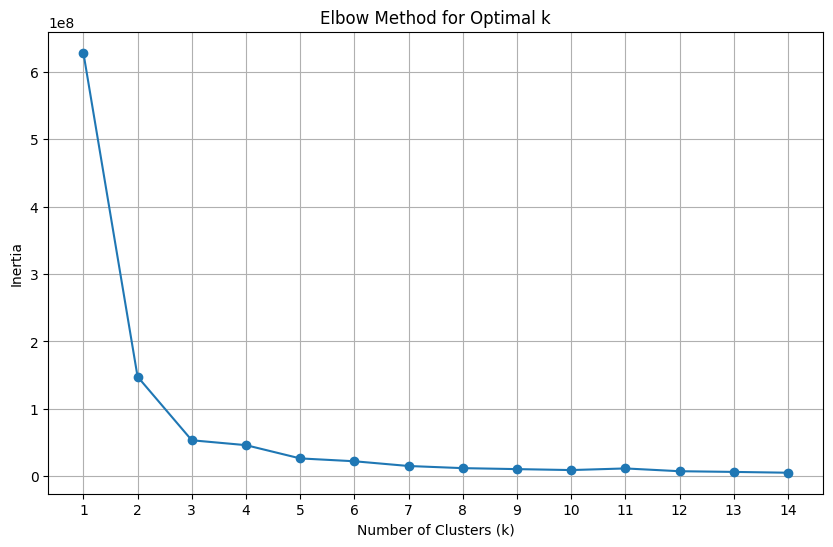

In [5]:
# Elbow Method to find optimal number of clusters

import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = df0

inertia = []
k_values = range(1, 15)  # Test for k from 1 to 15

for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df[['X', 'Y']])
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid()
plt.show()

In [6]:
import plotly.express as px

# Choose the optimal number of clusters based on the Elbow plot
optimal_k = 4  # Replace this value based on the Elbow plot observation


# Apply KMeans clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k)
df['tree_group'] = kmeans.fit_predict(df[['X', 'Y']])

# Display the DataFrame with tree group
print(df)


# plotly
title = f'Scatter Plot Colored by Category, n={len(df)}, groupping: {optimal_k}'
fig = px.scatter(df, x='X', y='Y', color='tree_group', title=title, hover_name = 'Tree No.')

     Tree No.           X           Y  tree_group
0        T146  827956.460  840484.030           2
1        T147  827963.750  840483.450           2
2        T148  827970.440  840483.010           2
3        T151  827991.460  840480.370           2
4        T152  827998.880  840480.050           2
...       ...         ...         ...         ...
1513    AT296  829228.223  840509.458           3
1514    AT297  829229.876  840508.632           3
1515    AT299  829229.447  840508.351           3
1516    AT300  829282.429  840543.140           3
1517    AT301  829308.107  840561.412           3

[1516 rows x 4 columns]


# Same-size k-means clustering

## Clustering of Type 1 tree group with linear pattern in an area

Outcome: Each cluster provides similar group size
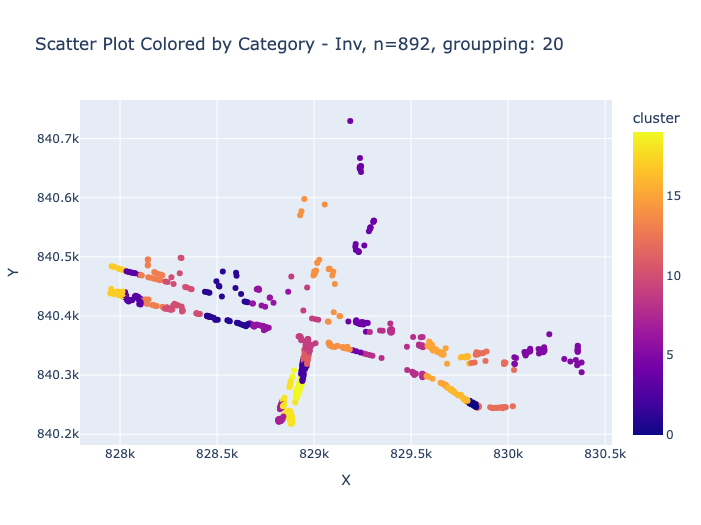

In [7]:
!pip install k-means-constrained

In [8]:
from k_means_constrained import KMeansConstrained
import math

In [9]:
def kClustering(dfTarget, treeGpSize):

  dfCluster = dfTarget
  print(f'n_clusters: {math.ceil(dfCluster.shape[0] / treeGpSize)}')
  print(f'treegp: {treeGpSize}')
  print(f'shape: {dfCluster.shape[0]}')
  n_clusters = math.ceil(dfCluster.shape[0] / treeGpSize)
  size_min = treeGpSize-2
  size_max = treeGpSize

  # Create a KMeansConstrained instance
  kmeans = KMeansConstrained(
      n_clusters = n_clusters,
      size_min = size_min,  # Minimum size for each cluster
      size_max = size_max,
      init = 'k-means++',
      random_state=0
  )

  print(dfCluster[['X', 'Y']])
  kmeans.fit(dfCluster[['X', 'Y']])

  dfCluster['cluster'] = kmeans.labels_

  cluster_counts = dfTarget['cluster'].value_counts()
  print(cluster_counts)

  # plotly
  title=f'Scatter Plot Colored by Category - Inv, n={dfCluster.shape[0]}, groupping: {n_clusters}'
  fig = px.scatter(df, x='X', y='Y', color='cluster', title=title, hover_name = 'Tree No.')
  fig.show()

  return dfCluster

In [10]:
treeGpSize = 45
df = dfInv
dfInvCluster = kClustering(df, treeGpSize)

n_clusters: 20
treegp: 45
shape: 892
               X           Y
0     827956.460  840484.030
1     827963.750  840483.450
2     827970.440  840483.010
3     827991.460  840480.370
4     827998.880  840480.050
...          ...         ...
1513  829228.223  840509.458
1514  829229.876  840508.632
1515  829229.447  840508.351
1516  829282.429  840543.140
1517  829308.107  840561.412

[892 rows x 2 columns]


/tmp/ipython-input-1915638918.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



cluster
17    45
3     45
6     45
1     45
9     45
11    45
14    45
4     45
8     45
15    45
16    45
12    45
7     45
18    45
2     45
19    45
0     45
5     44
13    42
10    41
Name: count, dtype: int64


## Clustering of Type 2 Tree Groups with Aggregation Patterns in Various Locations

Outcome : Each clustered group provides similar group size (the number of group depends on remainder of n / 50)
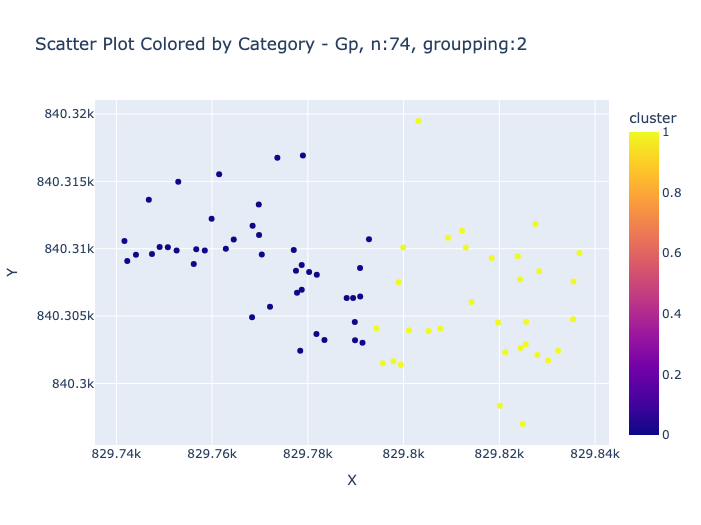

In [11]:
# Simple K-means

from sklearn.cluster import KMeans

treeGpSize2 = 50

def kmeansCluster(df):
  dfTemp = df

  n_clusters = math.ceil(dfTemp.shape[0]/treeGpSize2)

  kmeans = KMeans(n_clusters=n_clusters, random_state=42)
  dfTemp['cluster'] = kmeans.fit_predict(dfTemp[['X', 'Y']])  # Create 'clustered gp' column

  # plotly
  title=f'Scatter Plot Colored by Category - Gp, n:{len(dfTemp)}, groupping:{n_clusters}'
  fig = px.scatter(df, x='X', y='Y', color='cluster', title=title)
  fig.show()

  return dfTemp


In [12]:
dfGp = dfGp.copy()
dfGp.loc[:, 'treeGp'] = dfGp['Tree No.'].str.split('-').str[0].tolist()
gpLst = dfGp['treeGp'].unique()

dfGpCluster = pd.DataFrame(columns=['Tree No.', 'X', 'Y','cluster'])

for gp in gpLst:
  #dfTemp = dfGp[dfGp['treeGp'].isin([gp])]
  dfTemp = dfGp[dfGp['treeGp'] == gp]
  #print(dfTemp)

  if dfTemp.shape[0] > treeGpSize2:
    dfCluster = kmeansCluster(dfTemp)
    #dfCluster = kClustering(dfTemp, treeGpSize)
  else:
    dfCluster = dfTemp

  dfGpCluster = pd.concat([dfGpCluster, dfCluster], ignore_index=True)

/tmp/ipython-input-1630157389.py:18: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipython-input-305176871.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/tmp/ipython-input-305176871.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



/tmp/ipython-input-305176871.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [13]:
import numpy as np
dfGpCluster['groupping'] = np.where(
    dfGpCluster['cluster'].isna(),
    dfGpCluster['treeGp'],  # Value if constrained_cluster is NaN
    dfGpCluster['treeGp'] + '_' + dfGpCluster['cluster'].astype(str)  # Concatenation
)
dfGpCluster

,Tree No.,X,Y,cluster,treeGp,groupping
0,TG40A-T0001,830149.200,840315.150,NaN,TG40A,TG40A
1,TG40A-T0004,830143.010,840316.330,NaN,TG40A,TG40A
2,TG40A-T0005,830141.350,840313.720,NaN,TG40A,TG40A
3,TG40A-T0008,830136.620,840315.390,NaN,TG40A,TG40A
4,TG40A-T0012,830126.990,840314.460,NaN,TG40A,TG40A
...,...,...,...,...,...,...
619,TG345-T0006,829238.490,840555.405,NaN,TG345,TG345
620,TG345-T0007,829238.579,840556.204,NaN,TG345,TG345
621,TG345-T0013,829217.197,840523.090,NaN,TG345,TG345
622,TG345-T0014,829215.758,840518.902,NaN,TG345,TG345


In [14]:
dfGpCluster['groupping'].value_counts()

,count
groupping,
TG53C,50
TG39D,47
TG39C_0,44
TG39B_0,42
TG40A,34
TG39C_1,33
TG23,33
TG39B_1,32
TG19C,30


In [15]:
dfInvCluster.loc[:,'groupping'] = dfInvCluster['cluster']
dfInvCluster.loc[:,'treeGp'] = 'individualSector'
dfInvCluster

/tmp/ipython-input-2487809884.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-2487809884.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Tree No.,X,Y,cluster,groupping,treeGp
0,T146,827956.460,840484.030,17,17,individualSector
1,T147,827963.750,840483.450,17,17,individualSector
2,T148,827970.440,840483.010,17,17,individualSector
3,T151,827991.460,840480.370,17,17,individualSector
4,T152,827998.880,840480.050,17,17,individualSector
...,...,...,...,...,...,...
1513,AT296,829228.223,840509.458,4,4,individualSector
1514,AT297,829229.876,840508.632,4,4,individualSector
1515,AT299,829229.447,840508.351,4,4,individualSector
1516,AT300,829282.429,840543.140,4,4,individualSector


# Visualization Output

Visualization of Labeled Tree Groups After Clustering Algorithm

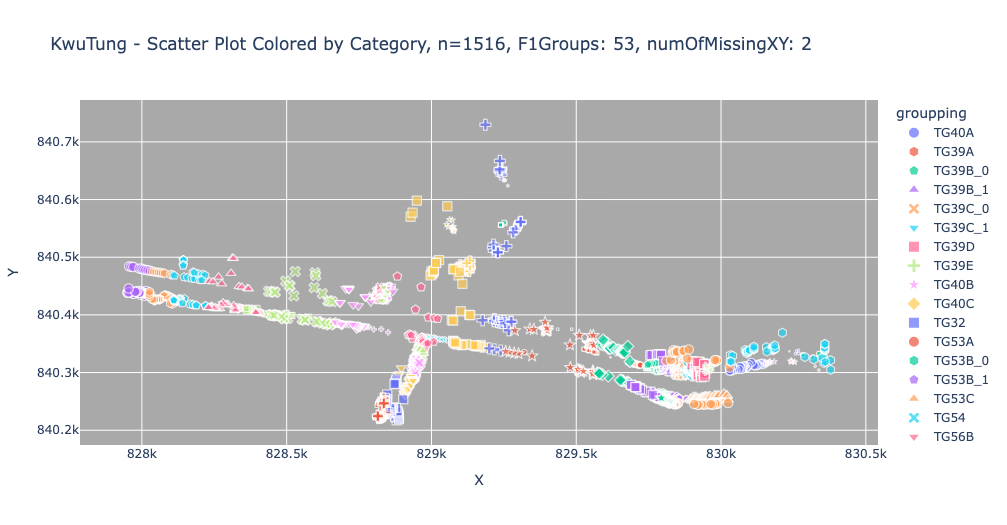

In [16]:
dfAll = pd.concat([dfGpCluster, dfInvCluster], ignore_index=True)
dfAll['groupping'].value_counts()

,count
groupping,
TG53C,50
TG39D,47
18,45
3,45
0,45
1,45
6,45
14,45
4,45


In [17]:
dfAll['grouppingCount'] = dfAll.groupby('groupping')['groupping'].transform('count')
dfAll

,Tree No.,X,Y,cluster,treeGp,groupping,grouppingCount
0,TG40A-T0001,830149.200,840315.150,NaN,TG40A,TG40A,34
1,TG40A-T0004,830143.010,840316.330,NaN,TG40A,TG40A,34
2,TG40A-T0005,830141.350,840313.720,NaN,TG40A,TG40A,34
3,TG40A-T0008,830136.620,840315.390,NaN,TG40A,TG40A,34
4,TG40A-T0012,830126.990,840314.460,NaN,TG40A,TG40A,34
...,...,...,...,...,...,...,...
1511,AT296,829228.223,840509.458,4,individualSector,4,45
1512,AT297,829229.876,840508.632,4,individualSector,4,45
1513,AT299,829229.447,840508.351,4,individualSector,4,45
1514,AT300,829282.429,840543.140,4,individualSector,4,45


In [18]:
import plotly.express as px

# Create a scatter plot

symbol_sequence= ['circle', 'hexagon', 'pentagon', 'triangle-up', 'x', 'triangle-down', 'square', 'cross', 'star', 'diamond', 'square']
color_discrete_sequence = ['blue', 'forestgreen', 'orange', 'green', 'brown', 'red', 'grey', 'dimgrey', 'purple', ]


title = f'KwuTung - Scatter Plot Colored by Category, n={(dfAll.shape[0])}, F1Groups: {str(len(dfAll['groupping'].unique()))}, numOfMissingXY: {numOfXYMissing}'

fig = px.scatter(dfAll, x='X', y='Y', color='groupping', title=title, hover_name = 'Tree No.', symbol='groupping', size='grouppingCount', size_max=10,
                 symbol_sequence= symbol_sequence, color_continuous_scale='Viridis', range_color=[100, 600])

fig.update_layout(
    plot_bgcolor='darkgray',  # Background color of the plot area
    paper_bgcolor='white'       # Background color of the entire figure
)

px.scatter()
# Show the plot
fig.show()
fig.write_html('KwuTungF1Distribution.html')

In [19]:
dfErrorX

,Tree No.,Chinese name,DBH (mm),Height (m),Crown spread (m),Recommendation,Additional Remarks,X,Y,count,group,grouppingCount,F2 Pruning,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
487,T814,(死樹),156.0,7.0,4.0,Retain,Felled,NaN,NaN,2,miss,NaN,NaN,NaN,NaN,NaN,NaN
610,T03212,血桐,NaN,NaN,NaN,Remove,Missing,NaN,NaN,2,miss,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
dfAll.to_excel('dfAll.xlsx', sheet_name='dfAll', index=False)

# ReSplitting data into 2 groups manually by QGIS for Better result 🙄

Sounth Bound and North Bound data

The data was manually split into Northbound and Southbound groups in QGIS to improve K-means clustering.

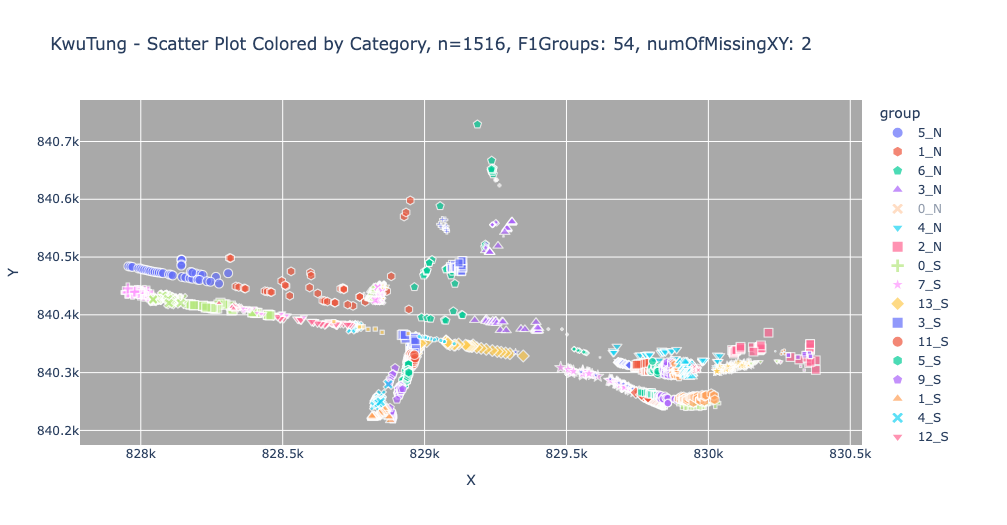

In [21]:
# https://docs.google.com/spreadsheets/d/1qWEyuezZVf_g4p76Ih3LWAmYQHoLmJz6KP0N-rm2SHc/edit?gid=2111668742#gid=2111668742
url = "https://docs.google.com/spreadsheets/d/1qWEyuezZVf_g4p76Ih3LWAmYQHoLmJz6KP0N-rm2SHc/gviz/tq?tqx=out:csv&gid=2111668742"

# Read the CSV data into a DataFrame
dfAll2 = pd.read_csv(url)
dfAll2 = dfAll2[~dfAll2['X'].isna()]
dfAll2 = dfAll2[['Tree No.', 'Chinese name', 'X', 'Y', 'group', 'grouppingCount']]
dfAll2

,Tree No.,Chinese name,X,Y,group,grouppingCount
0,T146,白千層,827956.460,840484.030,5_N,40.0
1,T147,白千層,827963.750,840483.450,5_N,40.0
2,T148,白千層,827970.440,840483.010,5_N,40.0
3,T151,秋楓,827991.460,840480.370,5_N,40.0
4,T152,秋楓,827998.880,840480.050,5_N,40.0
...,...,...,...,...,...,...
1513,AT296,血桐,829228.223,840509.458,3_N,43.0
1514,AT297,血桐,829229.876,840508.632,3_N,43.0
1515,AT299,血桐,829229.447,840508.351,3_N,43.0
1516,AT300,血桐,829282.429,840543.140,3_N,43.0


In [22]:
import plotly.express as px

# Create a scatter plot

symbol_sequence= ['circle', 'hexagon', 'pentagon', 'triangle-up', 'x', 'triangle-down', 'square', 'cross', 'star', 'diamond', 'square']
color_discrete_sequence = ['blue', 'forestgreen', 'orange', 'green', 'brown', 'red', 'grey', 'dimgrey', 'purple', ]


title = f'KwuTung - Scatter Plot Colored by Category, n={(dfAll2.shape[0])}, F1Groups: {str(len(dfAll2['group'].unique()))}, numOfMissingXY: {numOfXYMissing}'

fig = px.scatter(dfAll2, x='X', y='Y', color='group', title=title, hover_name = 'Tree No.', symbol='group', size='grouppingCount', size_max=10,
                 symbol_sequence= symbol_sequence, color_continuous_scale='Viridis', range_color=[100, 600], hover_data=['Chinese name', 'X', 'Y', 'group', 'grouppingCount'],)

fig.update_layout(
    plot_bgcolor='darkgray',  # Background color of the plot area
    paper_bgcolor='white'       # Background color of the entire figure
)

px.scatter()
# Show the plot
fig.show()
fig.write_html('KwuTungF1Distribution2.html')

# Inactive web map

The labeled data was exported to an interactive web map for Strategic Tree Management and Assessment:


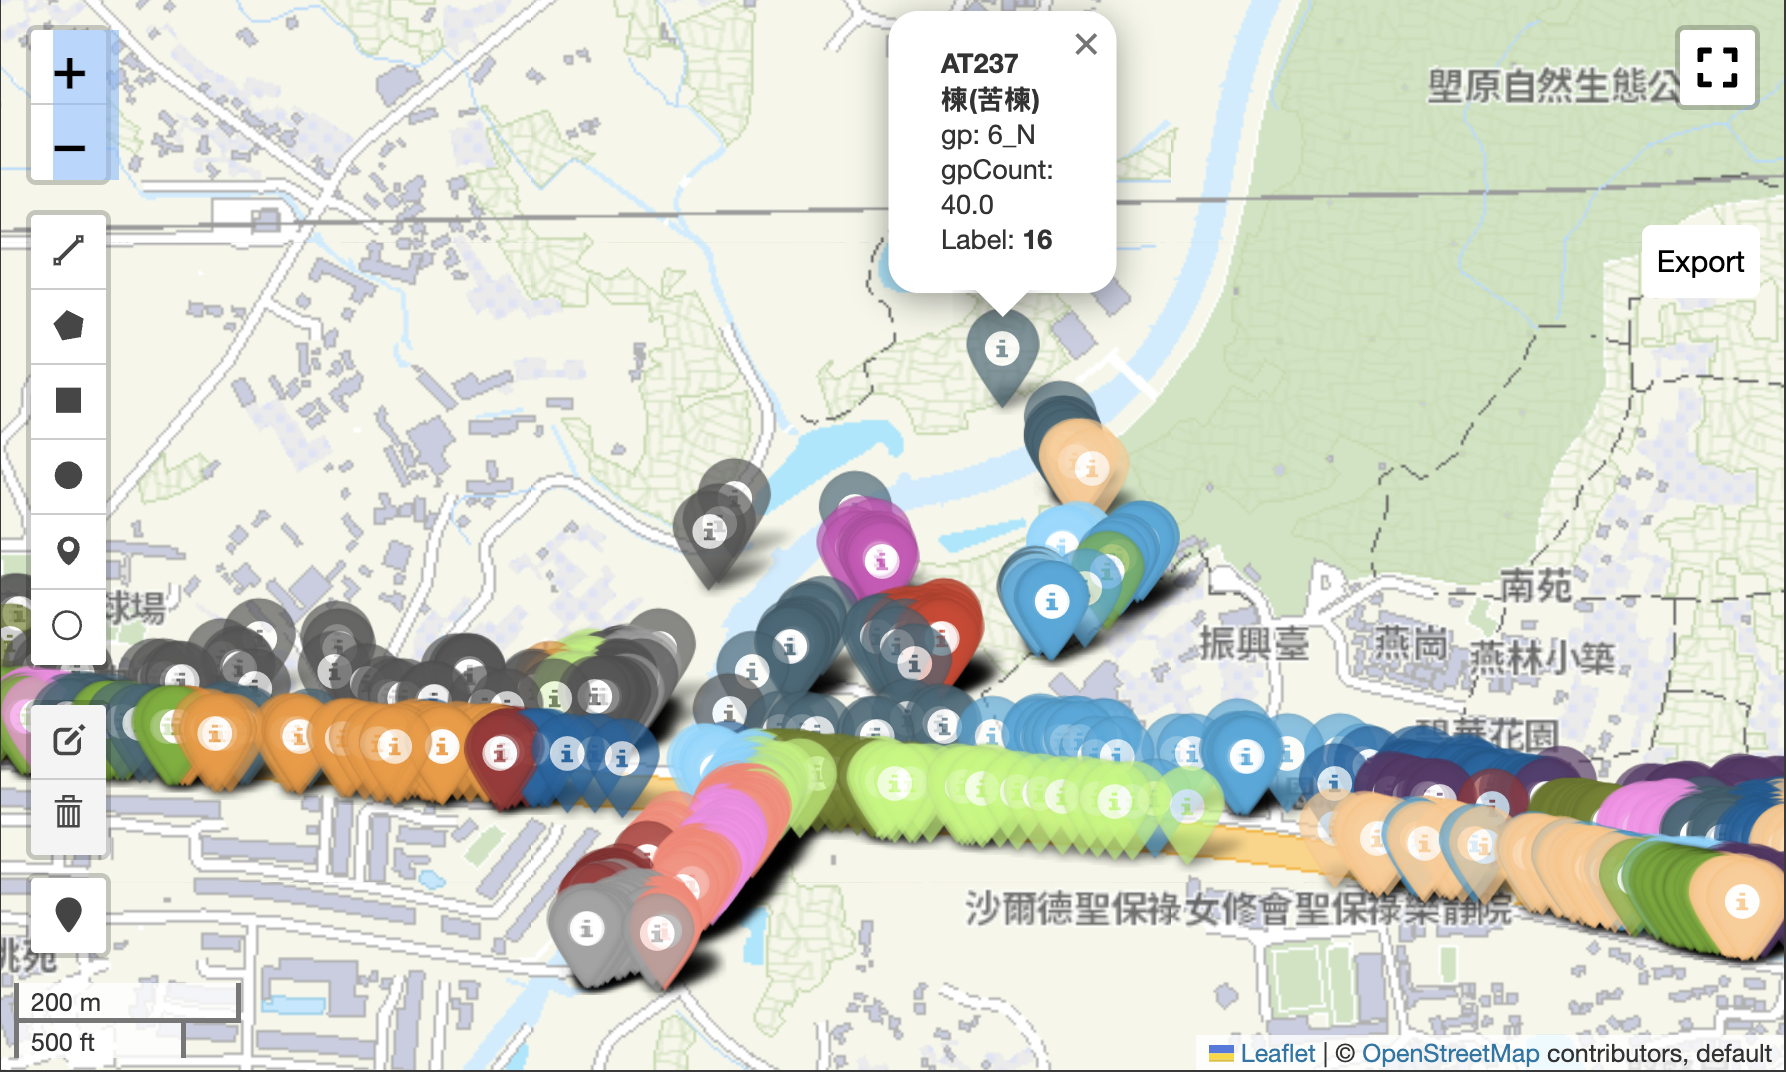




In [23]:
import folium
import folium.plugins
from folium import plugins
from folium.plugins import Draw
import geopandas as gpd

In [24]:
# Create point geometries
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
dfAll2['group_Encoded'] = le.fit_transform(dfAll2['group'])

geometry = gpd.points_from_xy(dfAll2.X, dfAll2.Y)
geo_df = gpd.GeoDataFrame(
    dfAll2, geometry=geometry
)
geo_df.set_crs(epsg=2326, inplace=True)
geo_df.to_crs(epsg=4326, inplace=True)

geo_df = geo_df.reset_index(drop=True)
geo_df.head()

,Tree No.,Chinese name,X,Y,group,grouppingCount,group_Encoded,geometry
0,T146,白千層,827956.46,840484.03,5_N,40.0,14,POINT (114.0961 22.50396)
1,T147,白千層,827963.75,840483.45,5_N,40.0,14,POINT (114.09617 22.50396)
2,T148,白千層,827970.44,840483.01,5_N,40.0,14,POINT (114.09623 22.50395)
3,T151,秋楓,827991.46,840480.37,5_N,40.0,14,POINT (114.09644 22.50393)
4,T152,秋楓,827998.88,840480.05,5_N,40.0,14,POINT (114.09651 22.50393)


In [25]:
color_mapping = {
    0: 'darkblue',
    1: 'beige',
    2: 'green',
    3: 'lightred',
    4: 'orange',
    5: 'lightgreen',
    6: 'gray',
    7: 'lightgray',
    8: 'purple',
    9: 'red',
    10: 'blue',
    11: 'lightblue',
    12: 'darkpurple',
    13: 'darkred',
    14: 'darkgreen',
    15: 'pink',
    16: 'cadetblue',
}


## Simple version

In [37]:
tileRoad = 'https://mapapi.geodata.gov.hk/gs/api/v1.0.0/xyz/label/hk/tc/WGS84/{z}/{x}/{y}.png'
tileurl ='https://mapapi.geodata.gov.hk/gs/api/v1.0.0/xyz/basemap/WGS84/{z}/{x}/{y}.png'

map = folium.Map(location=[22.50396, 114.0961], tiles="OpenStreetMap", zoom_start=14, max_zoom = 30,
                 zoom_snap = 0.1, name = 'empty_layer', prefer_canvas = True,  zoom_control=True, control_scale=True, bounceAtZoomLimits=True,)

OSM = folium.TileLayer(tiles ='OpenStreetMap', attr='default', overlay = False, opacity =1, show = False, min_zoom = 1, max_zoom = 30, max_native_zoom =20, name ='OSM', control=True).add_to(map)
Gov = folium.TileLayer(tiles = tileurl, attr='default', overlay = True, opacity = 1, show = True, control = True,  max_zoom = 30, max_native_zoom =20, name = 'HKMap').add_to(map)
folium.TileLayer(tiles = tileRoad, attr='default', overlay = True, opacity = 0.8, show = True, control = True,  max_zoom = 30, max_native_zoom =20, name = 'RoadLb').add_to(map)

geo_df_list = [[point.xy[1][0], point.xy[0][0]] for point in geo_df.geometry]

i = 0

marker_group = folium.FeatureGroup(name="Tree Markers").add_to(map)

for i, coordinates in enumerate(geo_df_list):
    group_value = geo_df['group_Encoded'][i] % 17
    icon_color = color_mapping.get(group_value, 'black')  # Default to black if not found

    # Create a marker with the folium.Icon
    folium.Marker(
        location=coordinates,
        popup=(
            "<b>" + str(geo_df['Tree No.'][i]) + "</b>"
            + "<br>"
            + "<b>"+str(geo_df['Chinese name'][i])+"</b>"
            + "<br>"
            + "gp: " + str(geo_df['group'][i])
            + "<br>"
            + "gpCount: " + str(geo_df['grouppingCount'][i])
            + "<br>"
            + "Label: " + "<b>" + str(geo_df['group_Encoded'][i])+"</b>"

        ),
        icon=folium.Icon(color=icon_color), #icon_color
        opacity=0.69
    ).add_to(marker_group)


plugins.Fullscreen(
    position='topright',
    title='Expand me',
    title_cancel='Exit me',
    force_separate_button=True
).add_to(map)

plugins.LocateControl(auto_start=False, position='bottomleft').add_to(map)


In [55]:
#map

In [ ]:
map.save('KwuTung202510.html')

## Self version

In [52]:
tileRoad = 'https://mapapi.geodata.gov.hk/gs/api/v1.0.0/xyz/label/hk/tc/WGS84/{z}/{x}/{y}.png'
tileurl ='https://mapapi.geodata.gov.hk/gs/api/v1.0.0/xyz/basemap/WGS84/{z}/{x}/{y}.png'
tileurls = 'https://mapapi.geodata.gov.hk/gs/api/v1.0.0/xyz/imagery/WGS84/{z}/{x}/{y}.png'  #max native 19

map = folium.Map(location=[22.50396, 114.0961], tiles="OpenStreetMap", zoom_start=14, max_zoom = 30,
                 zoom_snap = 0.1, name = 'empty_layer', prefer_canvas = True,  zoom_control=True, control_scale=True, bounceAtZoomLimits=True,)

OSM = folium.TileLayer(tiles ='OpenStreetMap', attr='default', overlay = False, opacity =1, show = False, min_zoom = 1, max_zoom = 30, max_native_zoom =20, name ='OSM', control=True).add_to(map)
Gov = folium.TileLayer(tiles = tileurl, attr='default', overlay = True, opacity = 1, show = True, control = True,  max_zoom = 30, max_native_zoom =20, name = 'HKMap').add_to(map)
folium.TileLayer(tiles = tileRoad, attr='default', overlay = True, opacity = 0.8, show = True, control = True,  max_zoom = 30, max_native_zoom =20, name = 'RoadLb').add_to(map)

#================================================================================== TrafficAids GOV
layerlist = list(range(10,26))
layerlist.extend([26,30,31,32,34,37,38,39,43,44,45,46,48,50,51,52])

folium.raster_layers.WmsTileLayer(url = 'https://portal.csdi.gov.hk/server/services/common/td_rcd_1638928986276_39755/MapServer/WMSServer?',
                                  layers = layerlist, #20
                                  transparent = True,
                                  control = True,
                                  fmt="image/png",
                                  name = 'TrafficAids',
                                  overlay = True,
                                  show = True,
                                  min_zoom = 17,
                                  max_zoom = 30, max_native_zoom =25,
                                  pixelated = False,
                                  mercator_project = True,
                                  opacity = 0.45
                                  ).add_to(map)
#==================================================================================

geo_df_list = [[point.xy[1][0], point.xy[0][0]] for point in geo_df.geometry]

i = 0

marker_group = folium.FeatureGroup(name="Tree Markers").add_to(map)

for i, coordinates in enumerate(geo_df_list):
    group_value = geo_df['group_Encoded'][i] % 17
    icon_color = color_mapping.get(group_value, 'black')  # Default to black if not found

    # Create a marker with the folium.Icon
    marker = folium.Marker(
        title = str(geo_df['Tree No.'][i]),
        location=coordinates,
        popup=(
            "<b>" + str(geo_df['Tree No.'][i]) + "</b>"
            + "<br>"
            + "<b>"+str(geo_df['Chinese name'][i])+"</b>"
            + "<br>"
            + "gp: " + str(geo_df['group'][i])
            + "<br>"
            + "gpCount: " + str(geo_df['grouppingCount'][i])
            + "<br>"
            + "Label: " + "<b>" + str(geo_df['group_Encoded'][i])+"</b>"

        ),
        icon=folium.Icon(color=icon_color), #icon_color
        opacity=0.69
    )
    marker.add_to(marker_group)

# Add the search plugin
search = plugins.Search(
    layer=marker_group,
    #geom_type='Point',
    placeholder='Search Tree No...',
    search_label='title',
    position='topleft',
    zoom=12,
    collapsed=True,
)
map.add_child(search)

plugins.Fullscreen(
    position='topright',
    title='Expand me',
    title_cancel='Exit me',
    force_separate_button=True
).add_to(map)

plugins.LocateControl(auto_start=False, position='bottomleft').add_to(map)

#================================================================================================================================= Draw
Draw(export=True,
     filename='drawing.geojson',
     position = 'topleft').add_to(map)
#================================================================================================================================


In [ ]:
#map

In [54]:
map.save('KwuTung202510_R.html')